### Flagging vendor's invoice for manual review 
#### Objective: Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery pattern in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value. 

1. Manual invoice review is time-consuming and does not scale with transition volume.
2. Abnormal freight charge, pricing deviation or delivery delays often indicate error, dispute, or compliance risks.
3. An automated flagging system enables the finance team to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically. 

In [42]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [43]:
conn = sqlite3.connect(r"C:\Users\singh\Desktop\Education\Invoice Intelligence ML Project\data\inventory.db")
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table';",conn)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [44]:
for table in tables["name"]:
    print("Table name", table)
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
    display(df)

Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [45]:
purchase_agg_df = pd.read_sql_query("""
SELECT 
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_items_quantity,
    SUM(p.Dollars) AS total_items_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
""", conn)

In [46]:
pd.read_sql_query("""
SELECT
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
FROM vendor_invoice vi
""", conn)

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [47]:
df = pd.read_sql_query("""

WITH purchase_agg AS (

    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_items_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_items_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi

LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber

""", conn)

In [48]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_items_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [49]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_items_dollars    0
avg_receiving_delay    0
dtype: int64

In [50]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_items_dollars    float64
avg_receiving_delay    float64
dtype: object

In [51]:
def create_invoice_risk_label(row):
    # invoice total mismatch with item-level total
    if (abs(row['invoice_dollars'] - row['total_items_dollars']) > 5):
        return 1
    
    #Abnormal high receving delay
    if row['avg_receiving_delay'] > 10:
        return 1
    return 0
df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

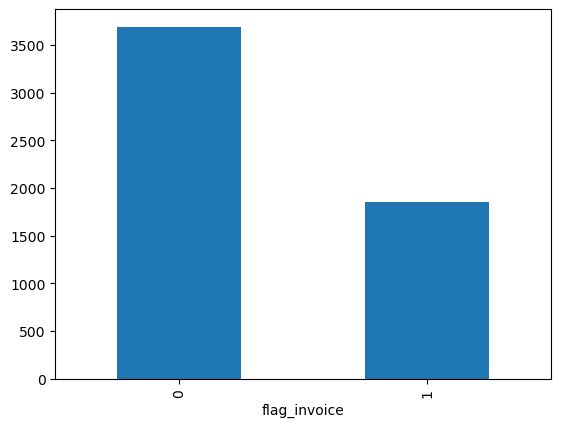

In [52]:
df['flag_invoice'].value_counts().plot(kind='bar')

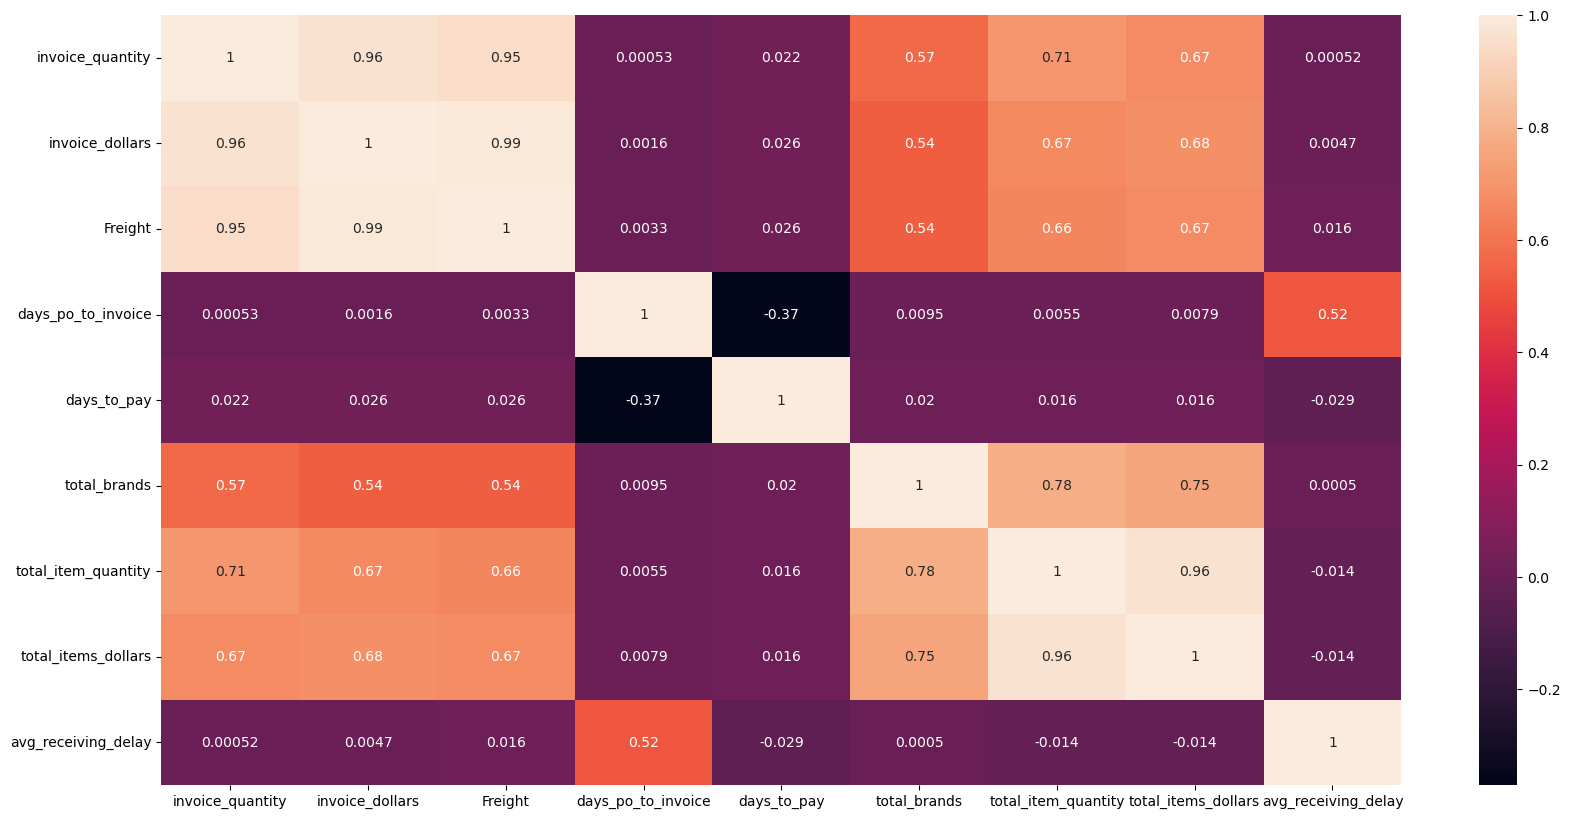

In [53]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,1:-1].corr() ,annot=True)
plt.show()

In [98]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [55]:
significant_features = []
non_significant_features = []
results = []

In [56]:
metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_items_dollars',
    'avg_receiving_delay'
]

In [99]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metrics": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)
        print(metric)
        print({
            "metric":metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })

days_to_pay
{'metric': 'days_to_pay', 'flagged_mean': np.float64(35.42), 'normal_mean': np.float64(35.49), 'p_value': np.float64(0.692)}
total_brands
{'metric': 'total_brands', 'flagged_mean': np.float64(42.29), 'normal_mean': np.float64(40.82), 'p_value': np.float64(0.508)}


In [100]:
non_significant_features

['days_to_pay', 'total_brands', 'days_to_pay', 'total_brands']

In [101]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_items_dollars',
 'avg_receiving_delay',
 'invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_items_dollars',
 'avg_receiving_delay']

In [102]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.739404869251578,
  'Precision': 0.738323120260665,
  'Recall': 0.739404869251578,
  'F1 Score': 0.7136876911704138},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9467989179440938,
  'Precision': 0.9467582252944315,
  'Recall': 0.9467989179440938,
  'F1 Score': 0.946468188429304},
 {'Model': 'Random Forest',
  'Accuracy': 0.9531109107303878,
  'Precision': 0.9562489192786756,
  'Recall': 0.9531109107303878,
  'F1 Score': 0.9522198963024057},
 {'metrics': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metrics': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metrics': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metrics': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean'

In [129]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_items_dollars','avg_receiving_delay']]
y = df['flag_invoice']

In [130]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_items_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0,8.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0,2.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0,3.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0,6.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0,8.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0,13.0


# Train Test Split

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

# Scaling
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [140]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [141]:
import warnings
warnings.filterwarnings('ignore')

In [142]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [143]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [144]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy  : {accuracy_score(y_test, preds):.2%}")
    print(f"Precision : {precision_score(y_test, preds, average='weighted'):.2%}")
    print(f"Recall    : {recall_score(y_test, preds, average='weighted'):.2%}")
    print(f"F1-Score  : {f1_score(y_test, preds, average='weighted'):.2%}")

In [146]:
evaluate_model(lr_model, X_test_scaled, y_test, "Logistic Regression")
evaluate_model(dt_model, X_test_scaled, y_test, "Decision Tree Classifier")
evaluate_model(rf_model, X_test_scaled, y_test, "Random Forest Classifier")


Logistic Regression Performance:
Accuracy  : 73.85%
Precision : 73.88%
Recall    : 73.85%
F1-Score  : 71.11%

Decision Tree Classifier Performance:
Accuracy  : 94.68%
Precision : 94.68%
Recall    : 94.68%
F1-Score  : 94.65%

Random Forest Classifier Performance:
Accuracy  : 95.31%
Precision : 95.62%
Recall    : 95.31%
F1-Score  : 95.22%


In [147]:
rf_model.feature_importances_

array([0.11256546, 0.11322923, 0.09186419, 0.0567393 , 0.1343592 ,
       0.03047572, 0.16214688, 0.29862001])

In [148]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by='importance',ascending=False)

feature_importance

,feature,importance
7,avg_receiving_delay,0.298620
6,total_items_dollars,0.162147
4,total_item_quantity,0.134359
1,invoice_dollars,0.113229
0,invoice_quantity,0.112565
2,Freight,0.091864
3,total_brands,0.056739
5,days_po_to_invoice,0.030476


In [149]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

In [150]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy  : 95.31%
Precision : 95.62%
Recall    : 95.31%
F1-Score  : 95.22%


In [151]:
from sklearn.metrics import confusion_matrix

In [152]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[725,  52],
       [  0, 332]])

In [153]:
confusion_matrix(rf_model.predict(X_test_scaled), y_test)

array([[725,  52],
       [  0, 332]])

In [154]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}